<a href="https://colab.research.google.com/github/manishcodespace/deeplearn-project/blob/maihttps/BasicNNModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [24]:
# create a model class that inherit nn module
# input layer (4 features of the flower) ---> Hidder layer1(Number of neuron) ----> Hidder layer2(Number of neuron) ---->
# Hidden Layer3(Number of neuron)----> output layer
class Model(nn.Module):
  def __init__(self, input_features = 4, h1=8, h2=9, output_features=3):
    super().__init__()
    # Input layer
    self.fc1 = nn.Linear(input_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, output_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [25]:
# pick a manual see of randomization
torch.manual_seed(32)

# create an instance of model
mymodel = Model()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [28]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [29]:
# change last col to interger
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

my_df

/tmp/ipykernel_1318/3462210957.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [30]:
# Train test split! set(x, y)

x=my_df.drop('variety', axis=1)
y=my_df['variety']

In [31]:
# convert these two a numpy array
x=x.values
y=y.values

In [32]:
from sklearn.model_selection import train_test_split

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [33]:
# convert x features into float tensor
X_train = torch.FloatTensor(x_train)
X_test = torch.FloatTensor(x_test)

In [34]:
# convert y features into tensor long
Y_train = torch.LongTensor(y_train)
Y_test = torch.LongTensor(y_test)

In [35]:
import torch.nn as nn

# set criteria of model to measure the error, how far off the prediction are from

criterion = nn.CrossEntropyLoss()

# choose Adam optimizer , lr = learning rate
optimizer = torch.optim.Adam(mymodel.parameters(), lr=0.01)


In [36]:
# Train our model
# Epochs (one run through all the training data in our network)
epochs = 100
losses = []

for i in range(epochs):
  # go forward and get a prediction
  y_pred = mymodel.forward(X_train) # get predicted result

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, Y_train) # pridicted value vs Y_train value

  # keep track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} to  loss :{loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it backbard
  # thru network to fine tune weight
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 to  loss :1.1642626523971558
Epoch: 10 to  loss :0.9502732157707214
Epoch: 20 to  loss :0.7863701581954956
Epoch: 30 to  loss :0.6350343227386475
Epoch: 40 to  loss :0.4286562204360962
Epoch: 50 to  loss :0.2817978858947754
Epoch: 60 to  loss :0.170501247048378
Epoch: 70 to  loss :0.10465356707572937
Epoch: 80 to  loss :0.0738060399889946
Epoch: 90 to  loss :0.05845501646399498


Text(0.5, 0, 'Epoch')

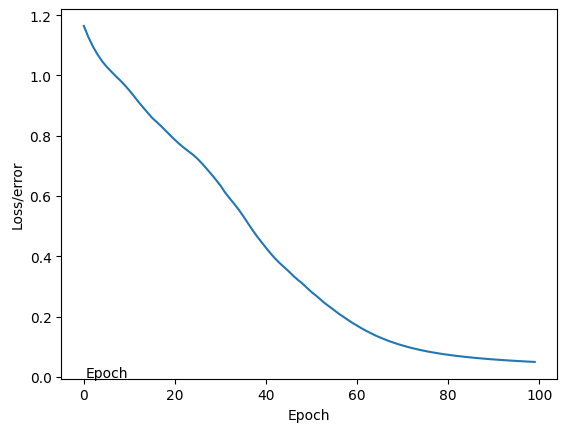

In [37]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('Loss/error')
plt.xlabel('Epoch')

plt.text(0.5, 0, 'Epoch')


In [38]:
with torch.no_grad():
  y_eval = mymodel.forward(X_test) # x_test are featurs from our set, y_eval will be prediction
  loss = criterion(y_eval, Y_test) # Find the loss or error

In [39]:
loss

tensor(0.1240)

In [40]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = mymodel.forward(data)

    if y_test[i] == 0:
      x = 'Setosa'
    elif y_test[i] == 1:
      x = 'Versicolor'
    else:
      x = 'Virginica'

    # will tell us what type of flower class our network think it is
    print(f' {i+1}.) {str(y_val)} \t {x} \t  {y_val.argmax().item()}')

    # correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'we got {correct} correct!')

 1.) tensor([-7.2038,  2.1721,  5.4994]) 	 Virginica 	  2
 2.) tensor([-9.1732,  1.3745,  7.8775]) 	 Virginica 	  2
 3.) tensor([-10.1985,   1.7705,   8.6772]) 	 Virginica 	  2
 4.) tensor([-3.0827,  4.1812, -0.1920]) 	 Versicolor 	  1
 5.) tensor([-8.3784,  2.0315,  6.6663]) 	 Virginica 	  2
 6.) tensor([-1.5283,  4.3402, -1.9532]) 	 Versicolor 	  1
 7.) tensor([-6.5455,  2.5353,  4.4948]) 	 Virginica 	  2
 8.) tensor([-2.5963,  4.2664, -0.8098]) 	 Versicolor 	  1
 9.) tensor([-7.2847,  2.3287,  5.3471]) 	 Virginica 	  2
 10.) tensor([-9.6250,  1.4546,  8.2592]) 	 Virginica 	  2
 11.) tensor([-5.8126,  2.7934,  3.5324]) 	 Virginica 	  2
 12.) tensor([  7.1656,   1.4196, -11.7688]) 	 Setosa 	  0
 13.) tensor([  6.4275,   1.2548, -10.5445]) 	 Setosa 	  0
 14.) tensor([-0.5550,  3.7271, -2.5152]) 	 Versicolor 	  1
 15.) tensor([  6.1486,   1.6963, -10.5360]) 	 Setosa 	  0
 16.) tensor([-5.4478,  3.2660,  2.8794]) 	 Virginica 	  1
 17.) tensor([  6.4697,   1.4848, -10.8310]) 	 Setosa 	  0

In [41]:
# adding new data
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [42]:
# just predict the output, don't need to learn because training process is already done
with torch.no_grad():
  print(mymodel(new_iris))

tensor([  6.8775,   1.2704, -11.2076])


In [43]:
# save and load our neural network
torch.save(mymodel.state_dict(), 'my_new_iris_model.pt')
new_model = Model()

new_model.load_state_dict(torch.load('my_new_iris_model.pt'))


<All keys matched successfully>

In [44]:
# Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)